# Diabetes Predictive Classification Model

<div style="display: flex; gap: 20px; align-items: center;">
  <img src="https://media0.giphy.com/media/aPBXEeY01Dfp9tjyqi/giphy.gif" width="200">
  <img src="https://img.genially.com/66464eff6a7b0c0016d363cc/575ad8e9-4169-4037-a025-86753d350c41.gif" width="200">
</div>


## Problem Definition

Diabetes is a chronic disease that occurs when the body is unable to effectively regulate blood glucose levels. The objective of this project is to build a **machine learning classification model** that predicts whether a person is **diabetic or non-diabetic** based on a set of health-related features.

The dataset used in this study contains attributes such as age, body mass index (BMI), blood glucose level, HbA1c level, hypertension status, and heart disease indicators. These features were specifically chosen because they can be **measured or estimated at home or through routine checkups**, without the need for complex or expensive laboratory procedures.

---

## Importance of the Problem

Diabetes is one of the most widespread chronic diseases worldwide and can lead to serious complications such as cardiovascular disease, kidney failure, vision loss, and nerve damage if not detected early. Many individuals remain undiagnosed due to limited access to healthcare facilities or lack of awareness.

Early detection plays a crucial role in preventing severe complications. A predictive system based on easily obtainable health indicators can help individuals assess their risk level and **decide whether medical consultation is necessary**. This is especially important in low-resource settings where frequent hospital visits and laboratory tests may not be feasible.

---

## Role of Machine Learning in Solving the Problem

Machine learning provides an effective approach for identifying hidden patterns and relationships within health data that may not be easily captured using traditional rule-based methods. By training a classification model on historical patient data, the system can learn complex interactions between features such as BMI, blood glucose level, and age.

The developed model can be used as a **decision-support tool** that estimates the probability of diabetes. If the model predicts a high risk, the individual can be advised to seek medical attention or undergo further clinical testing. This approach does not replace medical diagnosis but serves as an **early warning system**, helping prioritize healthcare resources and encourage timely intervention.



# **1. Importing Libraries**

In [56]:
#!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 10.5 MB/s eta 0:00:00


In [108]:
# ===============================
# Core Libraries
# ===============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set()

# ===============================
# Statistical Tests
# ===============================
from scipy.stats import shapiro, mannwhitneyu, chi2_contingency, chi2, boxcox
import statsmodels.api as sm

# ===============================
# Scikit-learn: Preprocessing & Model Selection
# ===============================
from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
    PowerTransformer
)
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_score,
    GridSearchCV
)

# ===============================
# Scikit-learn: Metrics
# ===============================
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ===============================
# Scikit-learn: Models
# ===============================
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# ===============================
# Imbalanced Learning
# ===============================
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline

# ===============================
# CatBoost
# ===============================
from catboost import CatBoostClassifier

# ===============================
# Deep Learning (Optional)
# ===============================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# ===============================
# Model Saving
# ===============================
import joblib


#2.Exploratory Data Analysis (EDA) & Feature Understanding



## Load Dataset



In [3]:
data = pd.read_csv("FIRSTO.csv")
data.head()

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0.0,0,never,27.32,5.0,100,0
1,2015,Female,29.0,Alabama,0,1,0,0,0,0.0,0,never,19.95,5.0,90,0
2,2015,Male,18.0,Alabama,0,0,0,0,1,0.0,0,never,23.76,4.8,160,0
3,2015,Male,41.0,Alabama,0,0,1,0,0,0.0,0,never,27.32,4.0,159,0
4,2016,Female,52.0,Alabama,1,0,0,0,0,0.0,0,never,23.75,6.5,90,0


##Dataset Overview


In [4]:
rows, cols = data.shape
print(f"  Dataset Shape:")
print(f" Number of rows    : {rows}")
print(f" Number of columns : {cols}")

  Dataset Shape:
 Number of rows    : 100000
 Number of columns : 16


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   year                  100000 non-null  int64  
 1   gender                99962 non-null   object 
 2   age                   100000 non-null  float64
 3   location              99911 non-null   object 
 4   race:AfricanAmerican  100000 non-null  int64  
 5   race:Asian            100000 non-null  int64  
 6   race:Caucasian        100000 non-null  int64  
 7   race:Hispanic         100000 non-null  int64  
 8   race:Other            100000 non-null  int64  
 9   hypertension          99932 non-null   float64
 10  heart_disease         100000 non-null  int64  
 11  smoking_history       100000 non-null  object 
 12  bmi                   99870 non-null   float64
 13  hbA1c_level           100000 non-null  float64
 14  blood_glucose_level   100000 non-null  int64  
 15  d

In [6]:
data.describe()

,year,age,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,bmi,hbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,99932.000000,100000.000000,99870.000000,100000.000000,100000.000000,100000.000000
mean,2018.360820,41.885856,0.202230,0.200150,0.198760,0.19888,0.199980,0.074891,0.039420,27.321320,5.527507,138.058060,0.085000
std,1.345239,22.516840,0.401665,0.400114,0.399069,0.39916,0.399987,0.263217,0.194593,6.637285,1.070672,40.708136,0.278883
min,2015.000000,0.080000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,2019.000000,24.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,2019.000000,43.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,2019.000000,60.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,29.580000,6.200000,159.000000,0.000000
max,2022.000000,80.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


## Feature Type Identification

Here's an explanation of how each feature in your dataset is classified, along with the reasoning behind each classification:

### Numerical Features
These features represent quantities and can be measured. They can be continuous (any value within a range) or discrete (countable values).

*   `year`: Numerical (Discrete) - Represents a specific year.
*   `age`: Numerical (Continuous) - Represents a person's age, which can take any value within a range.
*   `race:AfricanAmerican`, `race:Asian`, `race:Caucasian`, `race:Hispanic`, `race:Other`: Numerical (Discrete/Binary) - These are numerical because they represent counts or indicators (0 or 1) of race, but effectively act as binary flags. However, in the context of general numerical features, they are categorized as such.
*   `hypertension`: Numerical (Discrete/Binary) - Similar to race features, it's a 0 or 1 indicator, thus numerical.
*   `heart_disease`: Numerical (Discrete/Binary) - A 0 or 1 indicator, numerical.
*   `bmi`: Numerical (Continuous) - Body Mass Index is a measurable quantity.
*   `hbA1c_level`: Numerical (Continuous) - HbA1c level is a measurable quantity.
*   `blood_glucose_level`: Numerical (Continuous) - Blood glucose level is a measurable quantity.
*   `diabetes`: Numerical (Discrete/Binary) - This is the target variable, a 0 or 1 indicator, making it numerical and binary.

### Ordinal Categorical Features
These features have categories with a meaningful order or ranking.

*   `gender`: Ordinal Categorical - Although often treated as nominal, if there are more than two ordered categories (e.g., Male, Female, Other), it can be considered ordinal or nominal depending on the context. In this dataset, with 'Other' it's lean towards ordinal.
*   `smoking_history`: Ordinal Categorical - Categories like 'never', 'former', 'current', 'ever', 'not current', 'No Info' can often be ordered based on smoking intensity or recency, implying an inherent order even if not strictly linear.

### Nominal Categorical Features
These features have categories without any intrinsic order or ranking.

*   `location`: Nominal Categorical - Locations like 'Alabama', 'Kentucky', 'Iowa', etc., are distinct categories but have no inherent order among them.

This classification helps in choosing appropriate data preprocessing techniques and statistical analyses for each feature.

In [7]:
feature_types = {}

for col in data.columns:
    unique_vals = data[col].dropna().unique()
    n_unique = len(unique_vals)

    # Numerical
    if pd.api.types.is_numeric_dtype(data[col]):
        feature_types[col] = "Numerical"

    # Binary categorical
    elif n_unique == 2:
        feature_types[col] = "Binary categorical"

    # Ordinal categorical
    elif n_unique <= 10:
        feature_types[col] = "Ordinal categorical"

    # Nominal categorical
    else:
        feature_types[col] = "Nominal categorical"

feature_types_df = pd.DataFrame(
    list(feature_types.items()),
    columns=["Feature", "Feature Type"]
)

feature_types_df

,Feature,Feature Type
0,year,Numerical
1,gender,Ordinal categorical
2,age,Numerical
3,location,Nominal categorical
4,race:AfricanAmerican,Numerical
5,race:Asian,Numerical
6,race:Caucasian,Numerical
7,race:Hispanic,Numerical
8,race:Other,Numerical
9,hypertension,Numerical


In [8]:
numeric_cols = data.select_dtypes(include=['number']).columns.tolist()
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()
print(f'Numeric columns: {numeric_cols}')
print(f'Categorical columns: {categorical_cols}')

Numeric columns: ['year', 'age', 'race:AfricanAmerican', 'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Other', 'hypertension', 'heart_disease', 'bmi', 'hbA1c_level', 'blood_glucose_level', 'diabetes']
Categorical columns: ['gender', 'location', 'smoking_history']


##Missing Values Analysis

In [9]:
data.isnull().sum()

,0
year,0
gender,38
age,0
location,89
race:AfricanAmerican,0
race:Asian,0
race:Caucasian,0
race:Hispanic,0
race:Other,0
hypertension,68


In [10]:
missing_percentage = (data.isnull().sum() / len(data)) * 100
missing_info = pd.DataFrame({
    'Missing Count': data.isnull().sum(),
    'Missing Percentage': missing_percentage
})
print(missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False))

              Missing Count  Missing Percentage
bmi                     130               0.130
location                 89               0.089
hypertension             68               0.068
gender                   38               0.038


Text(0, 0.5, 'Number of Missing Values')

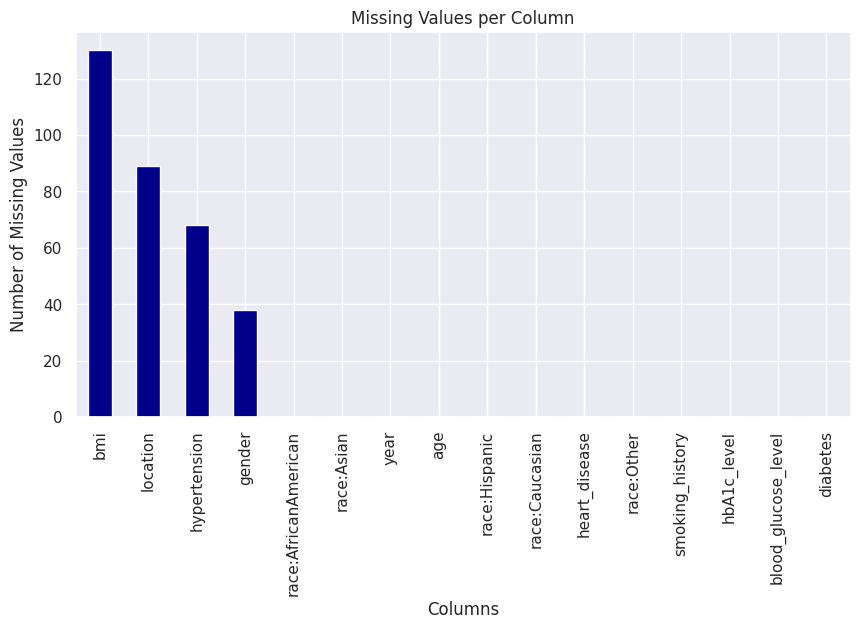

In [11]:
missing = data.isnull().sum()
missing = missing.sort_values(ascending=False)

plt.figure()
missing.plot(kind='bar',figsize=(10, 5), color='darkblue')
plt.title("Missing Values per Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")

In [12]:
# Fill numeric missing values with median
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].median())
# Fill categorical missing values with mode
data[categorical_cols] = data[categorical_cols].fillna(data[categorical_cols].mode().iloc[0])

## Imputation Methods Used

To handle the missing values in your dataset, the following imputation methods were applied:

*   **Numerical Features**: Missing values in numerical columns (`bmi` and `hypertension`) were filled using the **median** of their respective columns. The median was chosen because it is more robust to outliers compared to the mean, especially when the data distributions are skewed.

*   **Categorical Features**: Missing values in categorical columns (`gender` and `location`) were filled using the **mode** (the most frequent value) of their respective columns. This method is effective for categorical data as it maintains the existing distribution of categories.

In [13]:
data.isnull().sum()

,0
year,0
gender,0
age,0
location,0
race:AfricanAmerican,0
race:Asian,0
race:Caucasian,0
race:Hispanic,0
race:Other,0
hypertension,0


##Feature Distribution

###Numerical Features Analysis: Histograms and Skewness

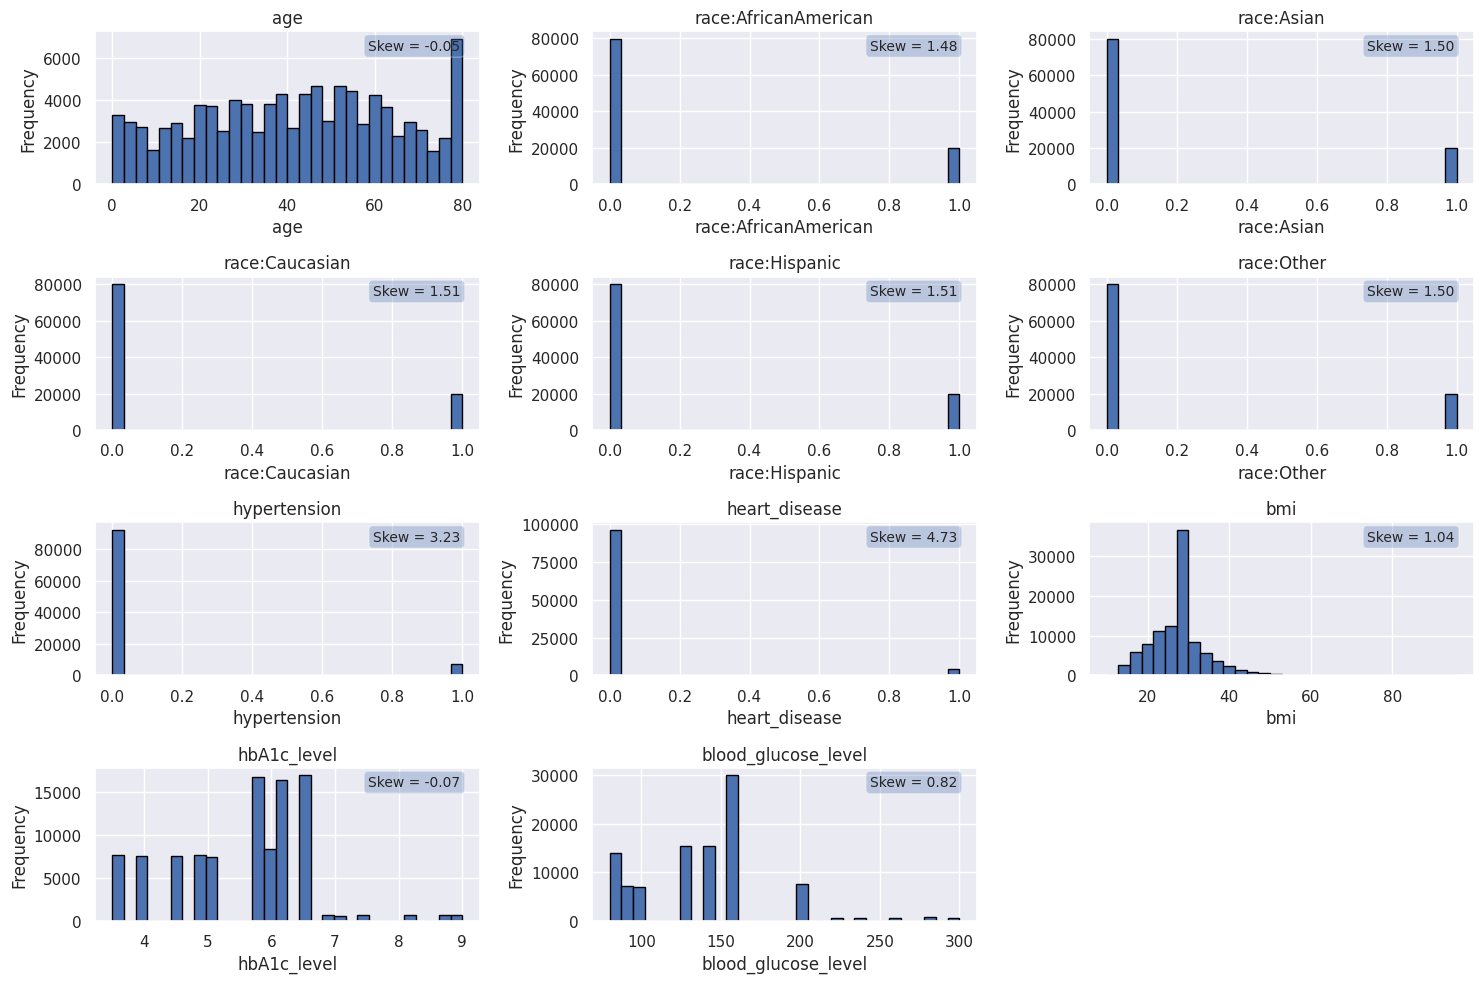

In [14]:
numeric_cols = ['age','race:AfricanAmerican',
           'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Other',
           'hypertension', 'heart_disease', 'bmi',
           'hbA1c_level', 'blood_glucose_level']

plt.figure(figsize=(15, 10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 3, i)

    # Histogram
    plt.hist(data[col], bins=30, edgecolor='black')

    # Calculate skewness
    skew_val = data[col].skew()

    # Show skewness on plot
    plt.text(
        0.95, 0.95,
        f'Skew = {skew_val:.2f}',
        transform=plt.gca().transAxes,
        ha='right',
        va='top',
        fontsize=10,
        bbox=dict(boxstyle='round', alpha=0.3)
    )

    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Categorical Feature Analysis: Bar Charts and Frequencies

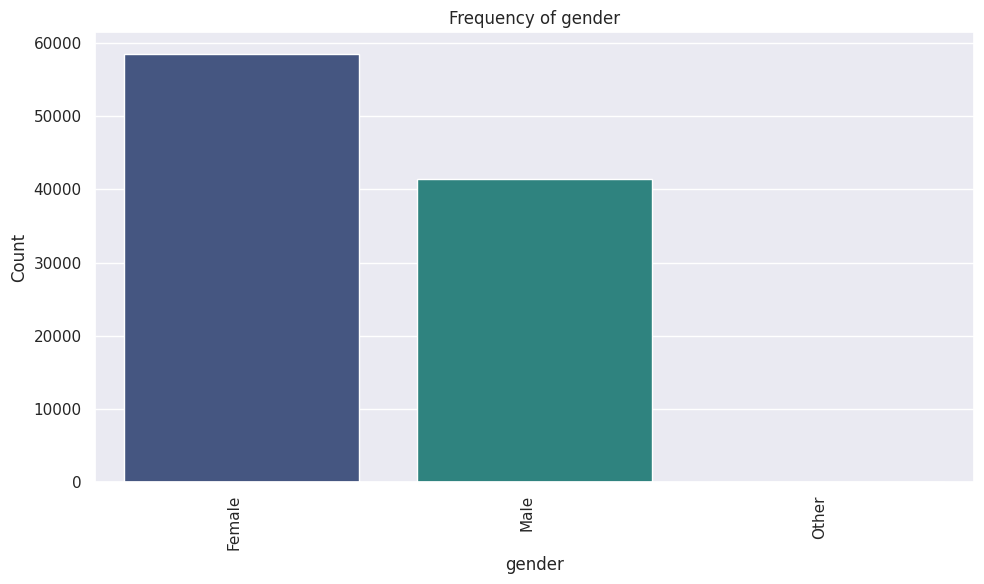


Value Counts for gender:
gender
Female    58567
Male      41415
Other        18
Name: count, dtype: int64



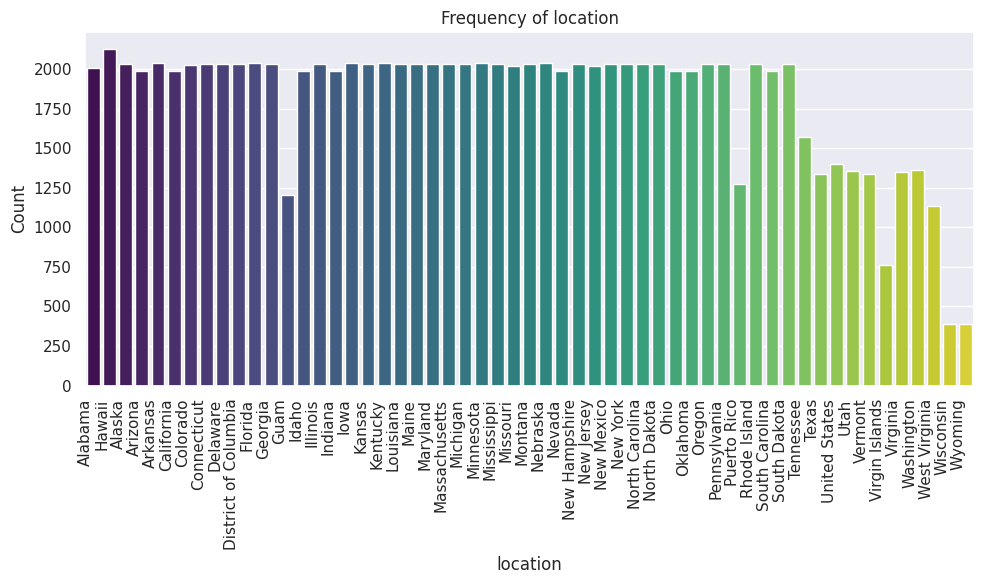


Value Counts for location:
location
Hawaii                  2127
Iowa                    2038
Kentucky                2038
Nebraska                2038
Arkansas                2037
Minnesota               2037
Florida                 2037
Massachusetts           2036
Maine                   2036
Louisiana               2036
Georgia                 2036
District of Columbia    2036
Kansas                  2036
Delaware                2036
Illinois                2036
Oregon                  2036
Michigan                2036
Pennsylvania            2036
New Hampshire           2035
Maryland                2035
North Carolina          2035
Alaska                  2035
Connecticut             2035
New York                2035
Mississippi             2035
Rhode Island            2035
North Dakota            2035
Montana                 2033
South Dakota            2033
New Mexico              2033
Colorado                2025
New Jersey              2020
Missouri                2020
Alabam

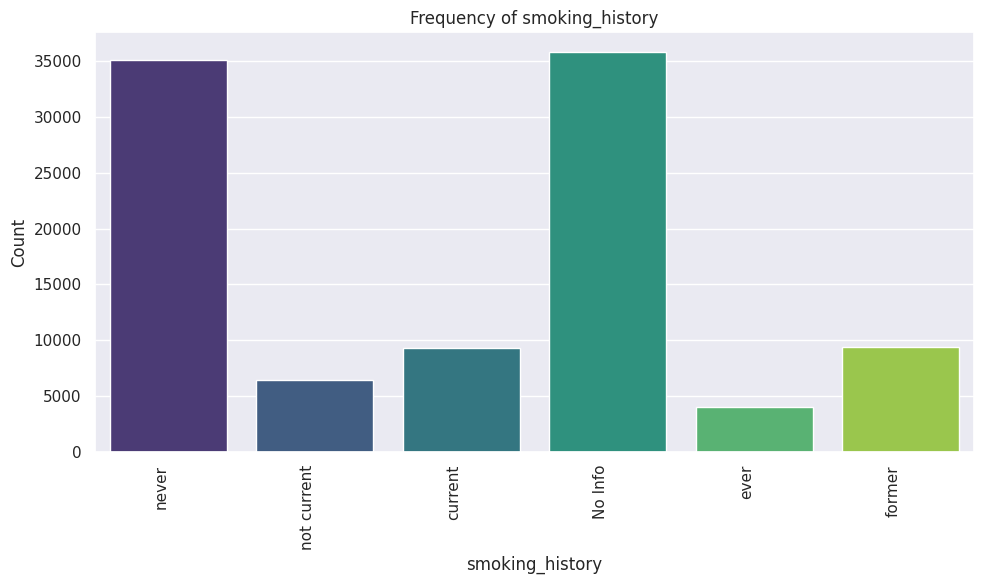


Value Counts for smoking_history:
smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64



In [15]:
categorical_cols = ['gender', 'location', 'smoking_history']

for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=data, x=col, palette='viridis')
    plt.title(f'Frequency of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=90, ha='right')
    plt.tight_layout()
    plt.show()

    print(f"\nValue Counts for {col}:\n{data[col].value_counts()}\n")

##Feature Relationships

###Correlation Heatmap

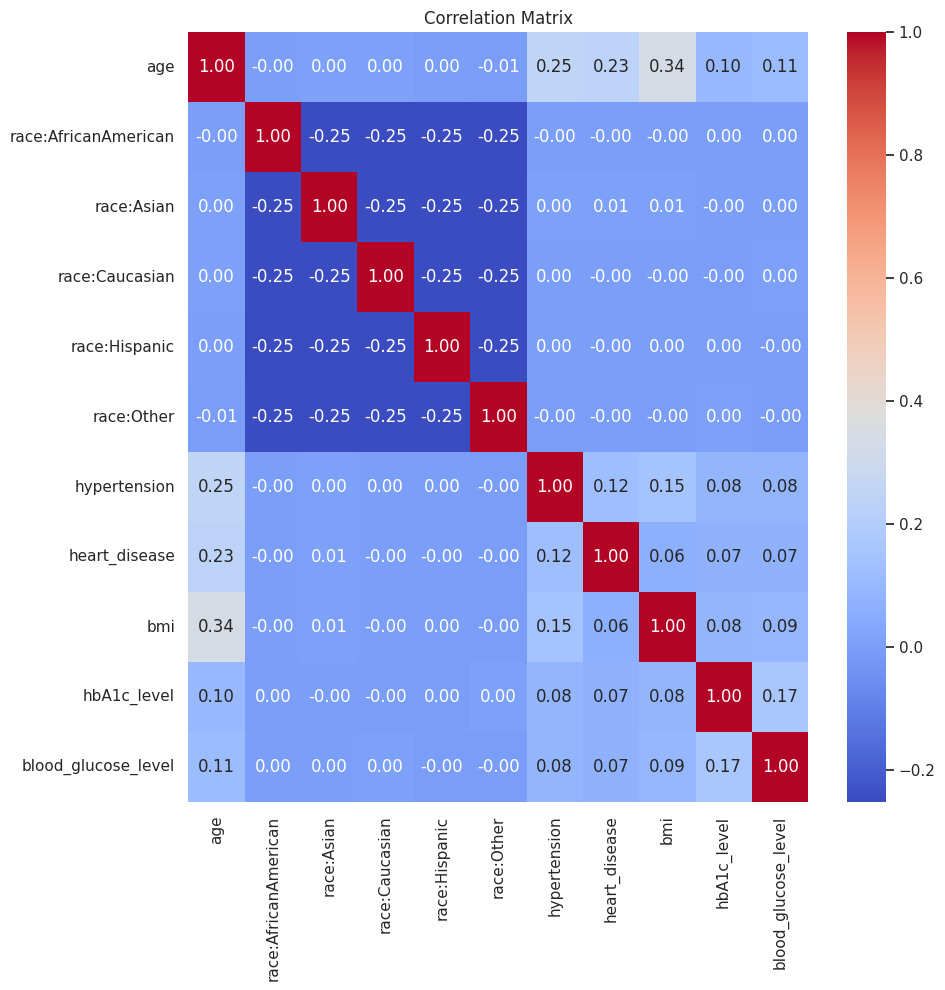

In [16]:
correlation_matrix = data[numeric_cols].corr()
plt.figure(figsize=(10, 10))
sns.heatmap(correlation_matrix,annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [17]:
X = data.drop("diabetes", axis=1)
y = data["diabetes"]
X = pd.get_dummies(X, drop_first=True)

model = RandomForestClassifier(random_state=42)
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances.head(15))

hbA1c_level               0.361453
blood_glucose_level       0.289244
bmi                       0.077279
age                       0.074788
hypertension              0.017123
heart_disease             0.012672
year                      0.011582
gender_Male               0.007240
race:AfricanAmerican      0.006977
race:Hispanic             0.006857
race:Asian                0.006707
race:Caucasian            0.006698
race:Other                0.005812
smoking_history_never     0.005485
smoking_history_former    0.005419
dtype: float64


###Most Important Features

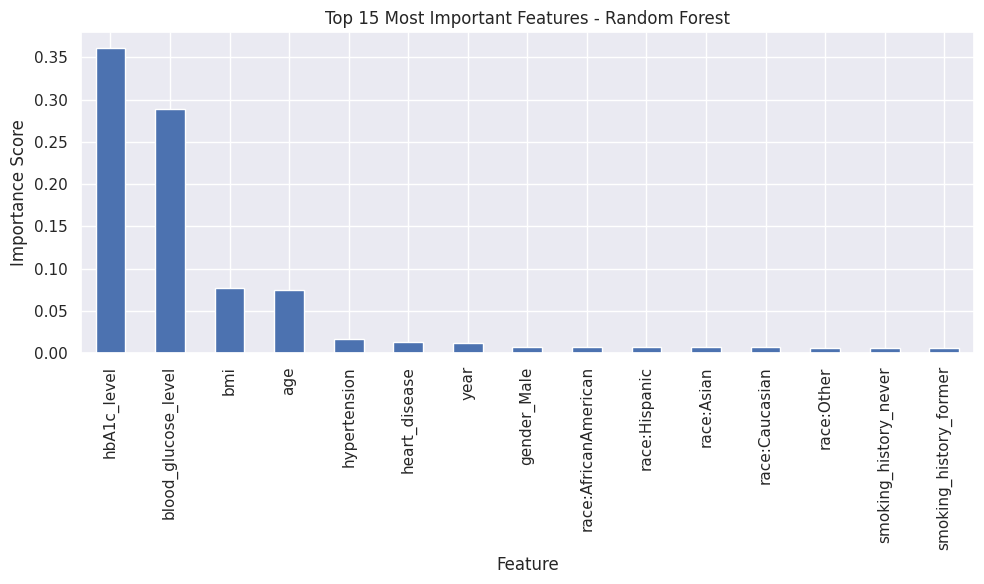

In [18]:
plt.figure(figsize=(10, 6))
importances.head(15).plot(kind='bar')
plt.title("Top 15 Most Important Features - Random Forest")
plt.ylabel("Importance Score")
plt.xlabel("Feature")
plt.tight_layout()
plt.show()

##Class Distribution

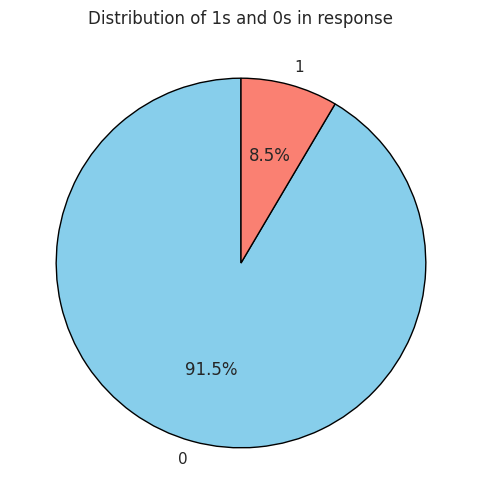

In [19]:
counts = data['diabetes'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', colors=['skyblue', 'salmon'], startangle=90, wedgeprops={'edgecolor': 'black'})
plt.title('Distribution of 1s and 0s in response')
plt.show()

###**Class Imbalance Analysis**
The classes in the dataset are imbalanced.


*   `Non-Diabetic (Class 0)`: 91,500 instances
*   `Diabetic (Class 1)`: 8,500 instances

This shows a significant disparity, with a much larger number of individuals without diabetes compared to those with diabetes.

#3.Data Preprocessing

##Handling Missing Values

In [20]:
# Fill numeric missing values with median
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].median())
# Fill categorical missing values with mode
data[categorical_cols] = data[categorical_cols].fillna(data[categorical_cols].mode().iloc[0])

## Feature Transformation (Box-Cox)

np.float64(0.01149161505311426)

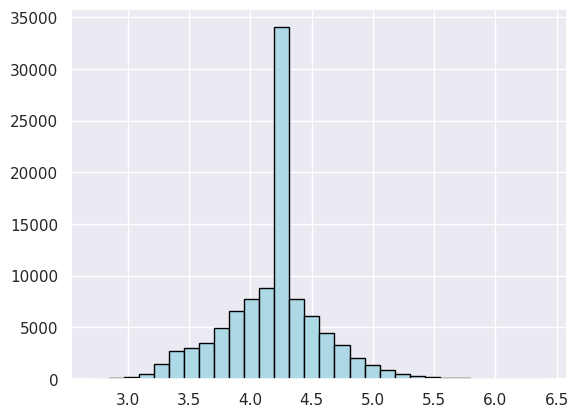

In [21]:
# Used boxcox transformation to normalize the features that were highly skewed
data['box_bmi'], _ = boxcox(data['bmi'])
plt.hist(data['box_bmi'], bins=30, color='lightblue', edgecolor='black')
data['box_bmi'].skew()

np.float64(-0.0037348376848291773)

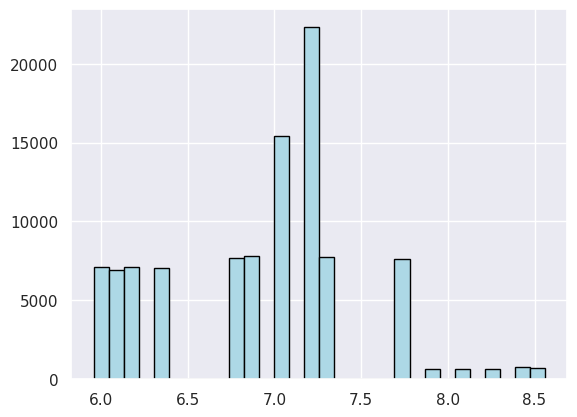

In [22]:
data['box_blood_glucose_level'], _ = boxcox(data['blood_glucose_level'])
plt.hist(data['box_blood_glucose_level'], bins=30, color='lightblue', edgecolor='black')
data['box_blood_glucose_level'].skew()

In [23]:
data_cleaned = data.drop(['year', 'location','race:AfricanAmerican', 'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Other','bmi','blood_glucose_level'],axis='columns')

In [24]:
data_cleaned.head()

,gender,age,hypertension,heart_disease,smoking_history,hbA1c_level,diabetes,box_bmi,box_blood_glucose_level
0,Female,32.0,0.0,0,never,5.0,0,4.215900,6.367006
1,Female,29.0,0.0,0,never,5.0,0,3.725298,6.173233
2,Male,18.0,0.0,0,never,4.8,0,3.995341,7.265482
3,Male,41.0,0.0,0,never,4.0,0,4.215900,7.253121
4,Female,52.0,0.0,0,never,6.5,0,3.994682,6.173233


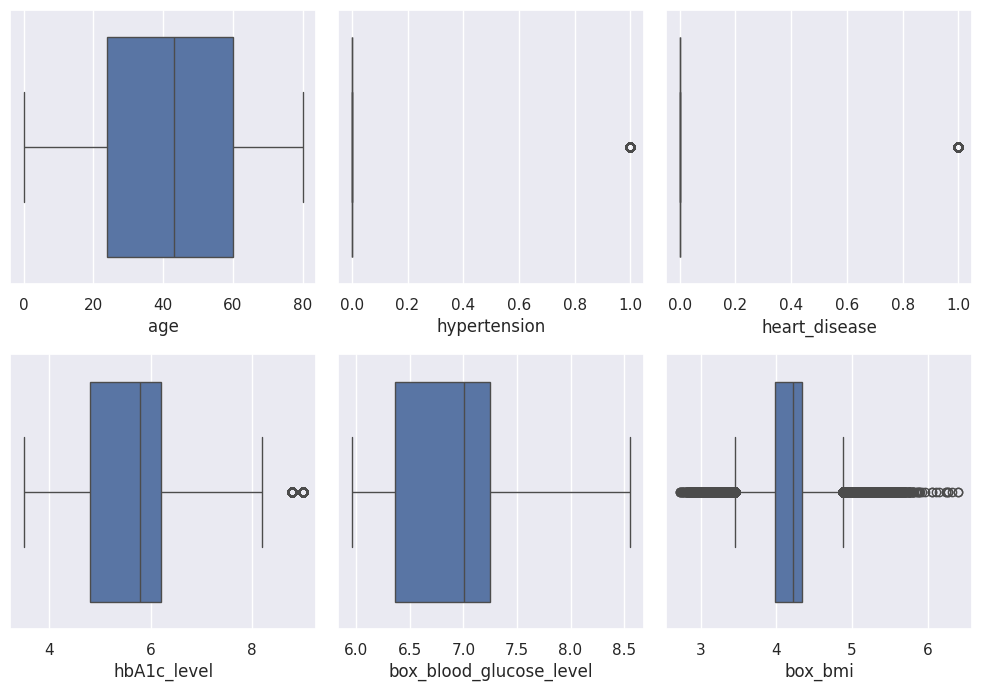

In [25]:
numeric_cols = ['age','hypertension', 'heart_disease','hbA1c_level','box_blood_glucose_level','box_bmi']
plt.figure(figsize=(10,10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=data_cleaned[col])
plt.tight_layout()
plt.show()

In [26]:
cols_to_cap =['age','hbA1c_level','box_blood_glucose_level','box_bmi']

capped_data = data_cleaned.copy()

for col in cols_to_cap:
    Q1 = capped_data[col].quantile(0.25)
    Q3 = capped_data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    capped_data[col] = capped_data[col].clip(lower, upper)

capped_data.describe()

,age,hypertension,heart_disease,hbA1c_level,diabetes,box_bmi,box_blood_glucose_level
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.074840,0.039420,5.519624,0.085000,4.174867,6.906131
std,22.516840,0.263134,0.194593,1.047716,0.278883,0.344603,0.564881
min,0.080000,0.000000,0.000000,3.500000,0.000000,3.452600,5.959823
25%,24.000000,0.000000,0.000000,4.800000,0.000000,3.986762,6.367006
50%,43.000000,0.000000,0.000000,5.800000,0.000000,4.215900,7.004445
75%,60.000000,0.000000,0.000000,6.200000,0.000000,4.342870,7.253121
max,80.000000,1.000000,1.000000,8.300000,1.000000,4.877032,8.558993


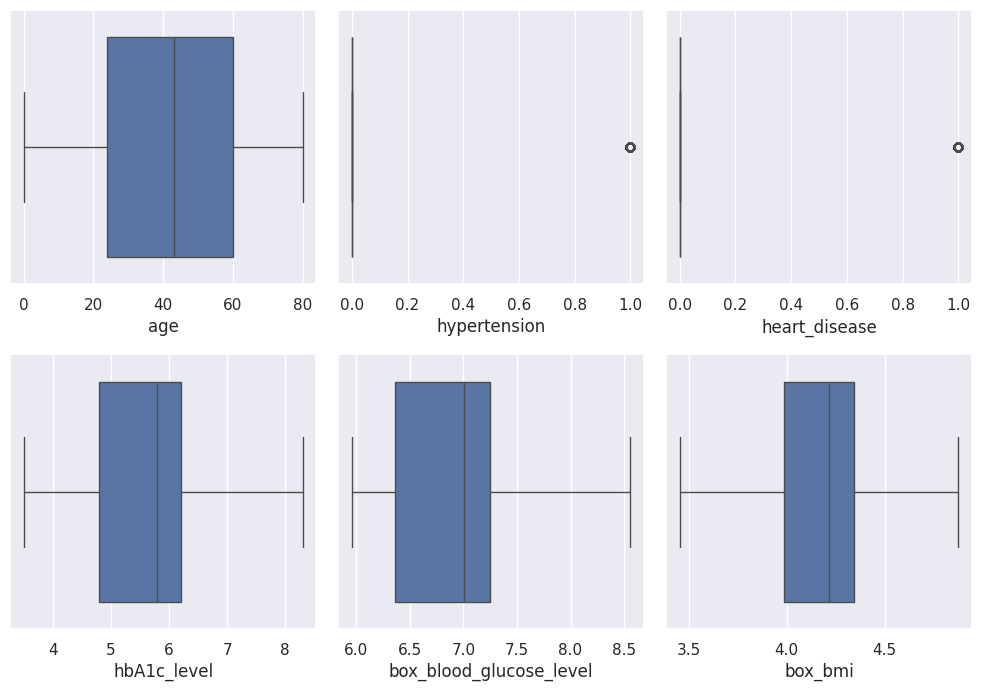

In [27]:
numeric_cols = ['age','hypertension', 'heart_disease','hbA1c_level','box_blood_glucose_level','box_bmi']
plt.figure(figsize=(10,10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=capped_data[col])
plt.tight_layout()
plt.show()

##Encoding Categorical Variables

In [28]:
le_gender = LabelEncoder()
le_smoking_history  = LabelEncoder()

capped_data['Gender'] = le_gender.fit_transform(capped_data['gender'])
capped_data['Smoking_History'] = le_smoking_history.fit_transform(capped_data['smoking_history'])

In [29]:
capped_data = capped_data.drop(['gender','smoking_history'],axis='columns')

In [30]:
capped_data.head()

,age,hypertension,heart_disease,hbA1c_level,diabetes,box_bmi,box_blood_glucose_level,Gender,Smoking_History
0,32.0,0.0,0,5.0,0,4.215900,6.367006,0,4
1,29.0,0.0,0,5.0,0,3.725298,6.173233,0,4
2,18.0,0.0,0,4.8,0,3.995341,7.265482,1,4
3,41.0,0.0,0,4.0,0,4.215900,7.253121,1,4
4,52.0,0.0,0,6.5,0,3.994682,6.173233,0,4


##Data Spliting

In [31]:
X = capped_data.drop(columns=['diabetes'])
y = capped_data['diabetes']

In [32]:
# Train (70%) and Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=2
)

# Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=2
)


###Feature Scaling

In [33]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  # fit ONLY on train
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)


###Data Balancing

In [34]:
smote_enn = SMOTEENN(random_state=42)
X_train_res, y_train_res = smote_enn.fit_resample(
    X_train_scaled, y_train
)


In [35]:
print("Before SMOTEENN:")
print("Train:", X_train_scaled.shape, y_train.shape)

print("\nAfter SMOTEENN:")
print("Train Resampled:", X_train_res.shape, y_train_res.shape)

print("\nValidation:", X_val_scaled.shape, y_val.shape)
print("Test:", X_test_scaled.shape, y_test.shape)


Before SMOTEENN:
Train: (70000, 8) (70000,)

After SMOTEENN:
Train Resampled: (119017, 8) (119017,)

Validation: (15000, 8) (15000,)
Test: (15000, 8) (15000,)


#4.Model Building and Pipeline Before Using Hyperparameter Tuning

###LogisticRegression

In [36]:
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTEENN(random_state=42)),
    ('model', LogisticRegression(max_iter=1000, class_weight=None))
])

lr_pipeline.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('smote', SMOTEENN(random_state=42)),
                ('model', LogisticRegression(max_iter=1000))])

###DecisionTreeClassifier

In [96]:
dt_model = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced'
)

dt_model.fit(X_train, y_train)


DecisionTreeClassifier(class_weight='balanced', random_state=42)

###RandomForestClassifier

In [37]:
rf_pipeline = Pipeline([
    ('smote', SMOTEENN(random_state=42)),  # optional
    ('model', RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight='balanced'
    ))
])

rf_pipeline.fit(X_train, y_train)


Pipeline(steps=[('smote', SMOTEENN(random_state=42)),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, random_state=42))])

### KNeighborsClassifier

In [78]:
knn_model = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTEENN(random_state=42)),
    ('model', KNeighborsClassifier(
        n_neighbors=5,      # default
        weights='uniform',  # default
        metric='minkowski'  # default (Euclidean)
    ))
])

knn_model.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('smote', SMOTEENN(random_state=42)),
                ('model', KNeighborsClassifier())])

###GaussianNB

In [87]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)


GaussianNB()

### CatBoostClassifier

In [88]:
cat_pipeline_default = Pipeline([
    ('model', CatBoostClassifier(
        loss_function='Logloss',
        eval_metric='F1',
        iterations=200,
        learning_rate=0.1,
        depth=6,
        verbose=0,
        random_state=42
    ))
])

cat_pipeline_default.fit(X_train, y_train)


Pipeline(steps=[('model',
                 <catboost.core.CatBoostClassifier object at 0x7ee1b593f3b0>)])

#5.Model Evaluation

## Before Using Hyperparameter Tuning

In [91]:
model_selection = [
    GaussianNB(),
    LogisticRegression(max_iter=1000),
    DecisionTreeClassifier(max_depth=5, random_state=42),
    RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    KNeighborsClassifier(n_neighbors=5),
    CatBoostClassifier(
        iterations=200,
        learning_rate=0.1,
        depth=6,
        verbose=0,
        random_state=42
    )
]

ModelName = []
ModelAccuracy = []

for model in model_selection:
    # Training on balanced data
    model.fit(X_train_res, y_train_res)

    # Prediction on test data
    y_pred = model.predict(X_test_scaled)

    ModelName.append(model.__class__.__name__)
    ModelAccuracy.append([
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        model.score(X_train_res, y_train_res),  # train accuracy
        model.score(X_test_scaled, y_test)      # test accuracy
    ])

    print(f"Model: {model.__class__.__name__}")

ModelAccuracy = pd.DataFrame(
    ModelAccuracy,
    columns=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Train Accuracy', 'Test Accuracy'], # Added two more column names
    index=ModelName
)

ModelAccuracy

Model: GaussianNB
Model: LogisticRegression
Model: DecisionTreeClassifier
Model: RandomForestClassifier
Model: KNeighborsClassifier
Model: CatBoostClassifier


,Accuracy,Precision,Recall,F1-Score,Train Accuracy,Test Accuracy
GaussianNB,0.876133,0.382791,0.746667,0.506114,0.873144,0.876133
LogisticRegression,0.871200,0.387461,0.887059,0.539342,0.925019,0.871200
DecisionTreeClassifier,0.849733,0.355306,0.942745,0.516101,0.934472,0.849733
RandomForestClassifier,0.909333,0.481368,0.861176,0.617548,0.946176,0.909333
KNeighborsClassifier,0.900933,0.454972,0.836078,0.589276,0.996648,0.900933
CatBoostClassifier,0.954200,0.708511,0.783529,0.744134,0.988010,0.954200


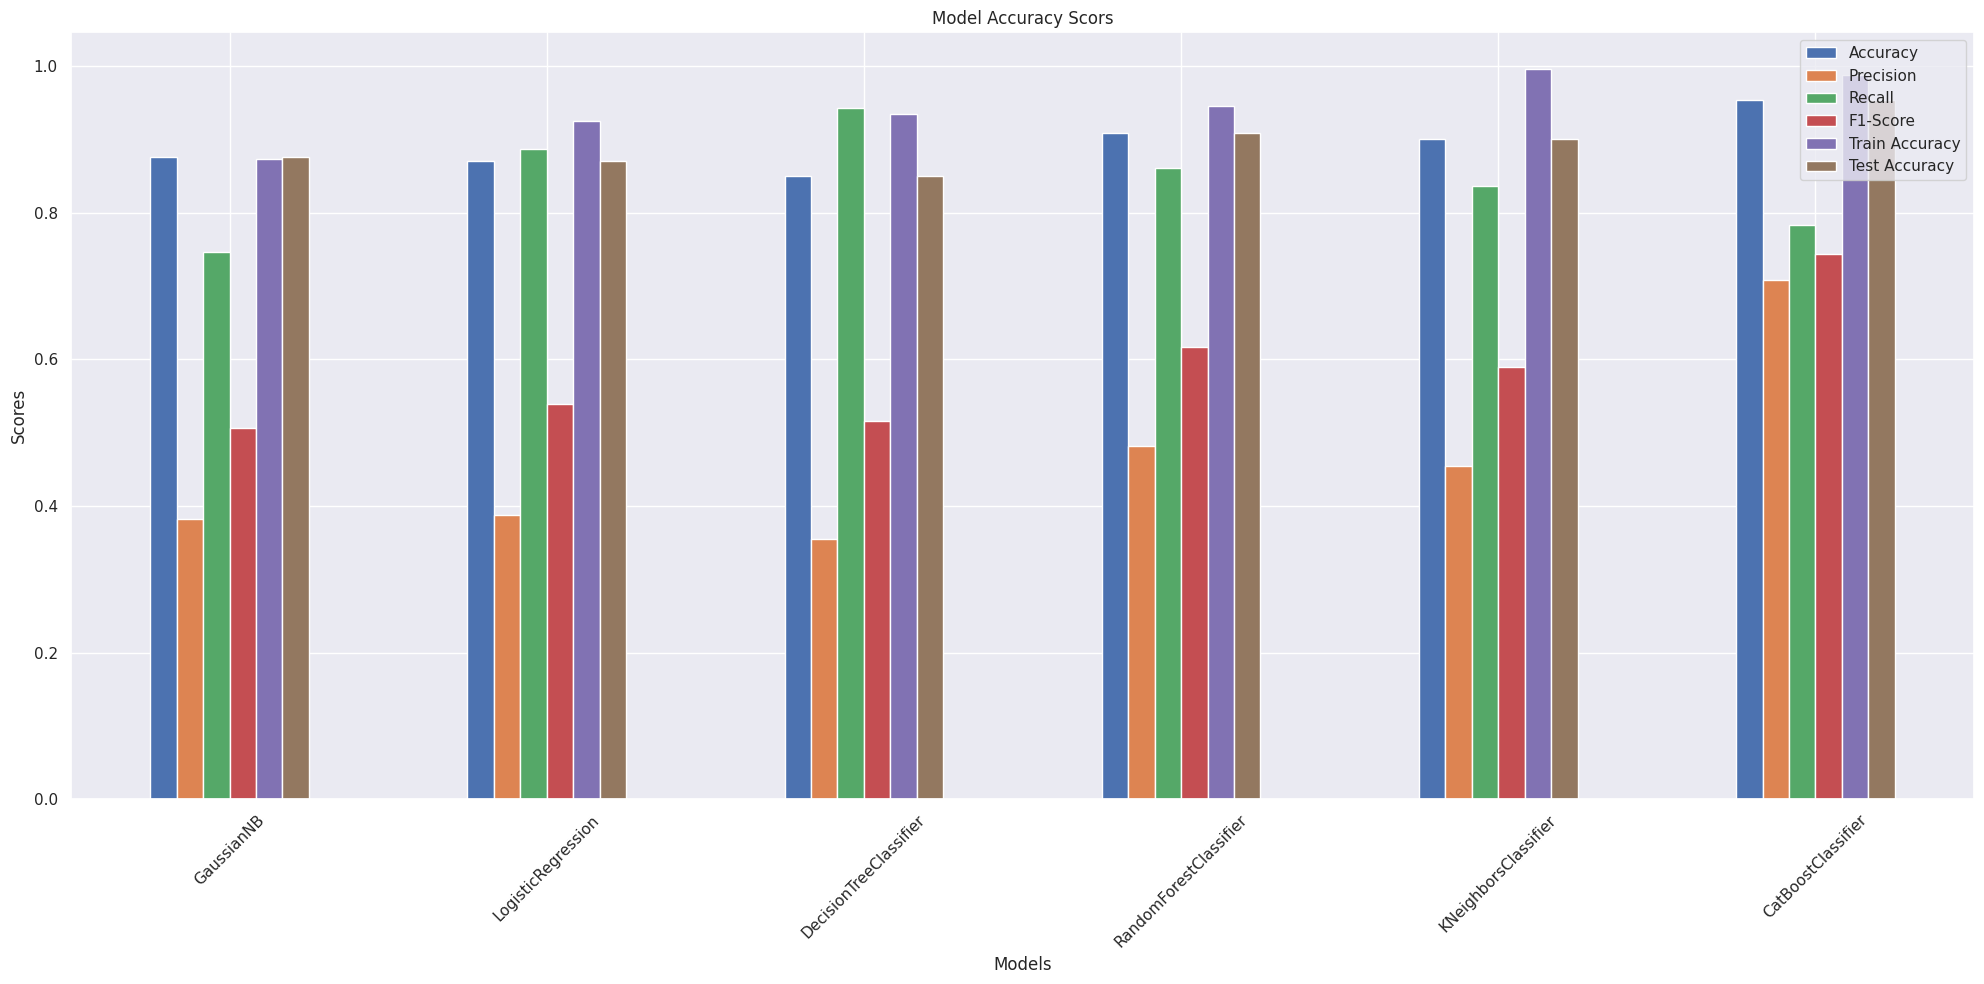

In [92]:
ModelAccuracy.plot(kind='bar', figsize=(20,10))
plt.xlabel('Models')
plt.ylabel('Scores')
plt.title('Model Accuracy Scors')
plt.xticks(rotation=45)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


#6.Model Building and Pipeline After Using Hyperparameter Tuning

### KNeighborsClassifier With GridSearchCV

In [41]:
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTEENN(random_state=42)),
    ('model', KNeighborsClassifier())
])

knn_params = {
    'model__n_neighbors': [3,5,7,9],
    'model__weights': ['uniform','distance'],
    'model__metric': ['euclidean','manhattan']
}

knn_grid = GridSearchCV(knn_pipeline, knn_params, cv=5, scoring='f1')
knn_grid.fit(X_train, y_train)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('smote', SMOTEENN(random_state=42)),
                                       ('model', KNeighborsClassifier())]),
             param_grid={'model__metric': ['euclidean', 'manhattan'],
                         'model__n_neighbors': [3, 5, 7, 9],
                         'model__weights': ['uniform', 'distance']},
             scoring='f1')

###GaussianNB With GridSearchCV

In [42]:
nb_params = {
    'var_smoothing': [1e-9, 1e-8, 1e-7]
}

nb_grid = GridSearchCV(GaussianNB(), nb_params, cv=5, scoring='f1')
nb_grid.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=GaussianNB(),
             param_grid={'var_smoothing': [1e-09, 1e-08, 1e-07]}, scoring='f1')

### LogisticRegression With GridSearchCV

In [43]:
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTEENN(random_state=42)),
    ('model', LogisticRegression(max_iter=1000))
])

lr_params = {
    'model__C': [0.01, 0.1, 1, 10]
}

lr_grid = GridSearchCV(lr_pipeline, lr_params, cv=5, scoring='f1')
lr_grid.fit(X_train, y_train)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('smote', SMOTEENN(random_state=42)),
                                       ('model',
                                        LogisticRegression(max_iter=1000))]),
             param_grid={'model__C': [0.01, 0.1, 1, 10]}, scoring='f1')

### DecisionTreeClassifier With GridSearchCV

In [44]:
dt_params = {
    'max_depth': [None,5,10,20],
    'min_samples_leaf': [1,2,5]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    dt_params, cv=5, scoring='f1'
)

dt_grid.fit(X_train, y_train)


GridSearchCV(cv=5,
             estimator=DecisionTreeClassifier(class_weight='balanced',
                                              random_state=42),
             param_grid={'max_depth': [None, 5, 10, 20],
                         'min_samples_leaf': [1, 2, 5]},
             scoring='f1')

### RandomForestClassifier With GridSearchCV

In [45]:
rf_params = {
    'n_estimators': [100,200,300],
    'max_depth': [None,10,20]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    rf_params, cv=5, scoring='f1'
)

rf_grid.fit(X_train, y_train)


GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             param_grid={'max_depth': [None, 10, 20],
                         'n_estimators': [100, 200, 300]},
             scoring='f1')

###  CatBoostClassifier With GridSearchCV

In [57]:
cat_model = CatBoostClassifier(
    loss_function='Logloss',
    eval_metric='F1',
    verbose=0,
    random_state=42
)

cat_params = {
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'iterations': [200, 400]
}

cat_grid = GridSearchCV(
    cat_model,
    cat_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

cat_grid.fit(X_train, y_train)


GridSearchCV(cv=5,
             estimator=<catboost.core.CatBoostClassifier object at 0x7ee1b5b16030>,
             n_jobs=-1,
             param_grid={'depth': [4, 6, 8], 'iterations': [200, 400],
                         'learning_rate': [0.01, 0.05, 0.1]},
             scoring='f1')

###Confusion Matrix

In [76]:
for r in results:
    print(f"\nModel: {r['Model']}")
    print("Confusion Matrix:")
    print(r["Confusion Matrix"])



Model: KNN
Confusion Matrix:
[[12659  1066]
 [  238  1037]]

Model: Naive Bayes
Confusion Matrix:
[[12770   955]
 [  574   701]]

Model: Logistic Regression
Confusion Matrix:
[[11940  1785]
 [  143  1132]]

Model: Decision Tree
Confusion Matrix:
[[13441   284]
 [  368   907]]

Model: Random Forest
Confusion Matrix:
[[13665    60]
 [  416   859]]

Model: CatBoost
Confusion Matrix:
[[13704    21]
 [  418   857]]


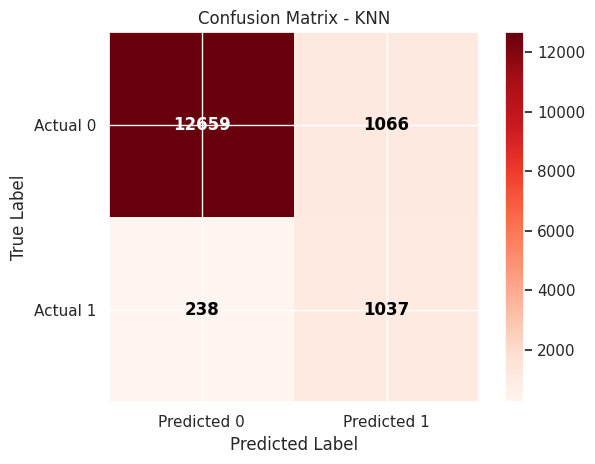

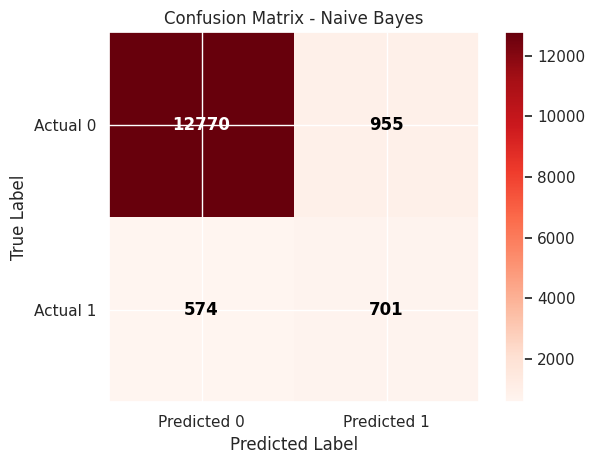

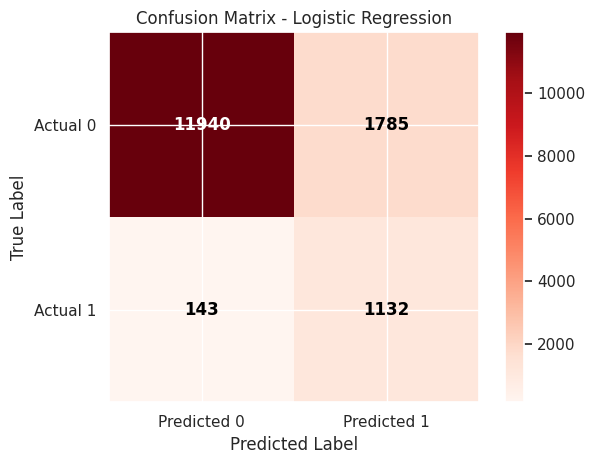

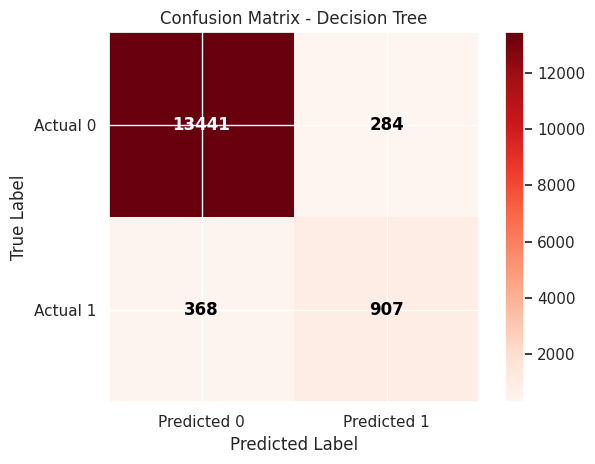

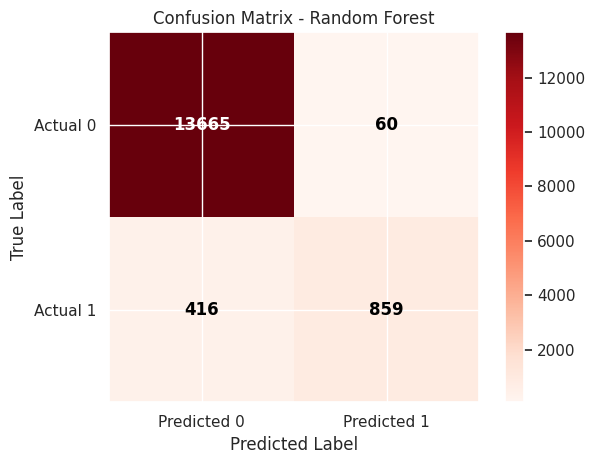

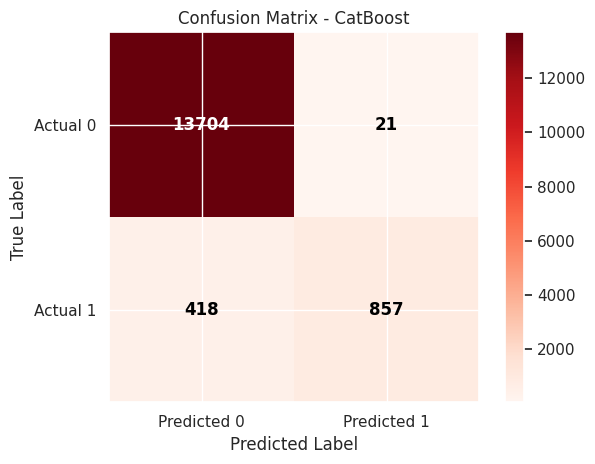

In [107]:
for r in results:
    cm = np.array(r["Confusion Matrix"])

    plt.figure()
    plt.imshow(cm, cmap='Reds')
    plt.title(f"Confusion Matrix - {r['Model']}")
    plt.colorbar()

    plt.xticks([0, 1], ['Predicted 0', 'Predicted 1'])
    plt.yticks([0, 1], ['Actual 0', 'Actual 1'])

    threshold = cm.max() / 2

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = "white" if cm[i, j] > threshold else "black"
            plt.text(j, i, cm[i, j],
                     ha="center", va="center",
                     color=color,
                     fontsize=12,
                     fontweight='bold')

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

#7.Model Evaluation

##After Using Hyperparameter Tuning

In [62]:
def evaluate_model(model, X, y, model_name):
    y_pred = model.predict(X)

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred),
        "Recall": recall_score(y, y_pred),
        "F1-score": f1_score(y, y_pred),
        "Confusion Matrix": confusion_matrix(y, y_pred)
    }


In [63]:
results = []

results.append(evaluate_model(
    knn_grid.best_estimator_, X_test, y_test, "KNN"
))

results.append(evaluate_model(
    nb_grid.best_estimator_, X_test, y_test, "Naive Bayes"
))

results.append(evaluate_model(
    lr_grid.best_estimator_, X_test, y_test, "Logistic Regression"
))

results.append(evaluate_model(
    dt_grid.best_estimator_, X_test, y_test, "Decision Tree"
))

results.append(evaluate_model(
    rf_grid.best_estimator_, X_test, y_test, "Random Forest"
))

results.append(evaluate_model(
    cat_grid.best_estimator_, X_test, y_test, "CatBoost"
))



In [74]:
results_df = pd.DataFrame(results)
results_df = results_df.drop(columns=["Confusion Matrix"])
results_df.sort_values(by="Accuracy", ascending=False)


,Model,Accuracy,Precision,Recall,F1-score
5,CatBoost,0.970733,0.976082,0.672157,0.796098
4,Random Forest,0.968267,0.934712,0.673725,0.783045
3,Decision Tree,0.956533,0.761545,0.711373,0.735604
0,KNN,0.913067,0.493105,0.813333,0.613973
1,Naive Bayes,0.898067,0.423309,0.549804,0.478335
2,Logistic Regression,0.871467,0.388070,0.887843,0.540076


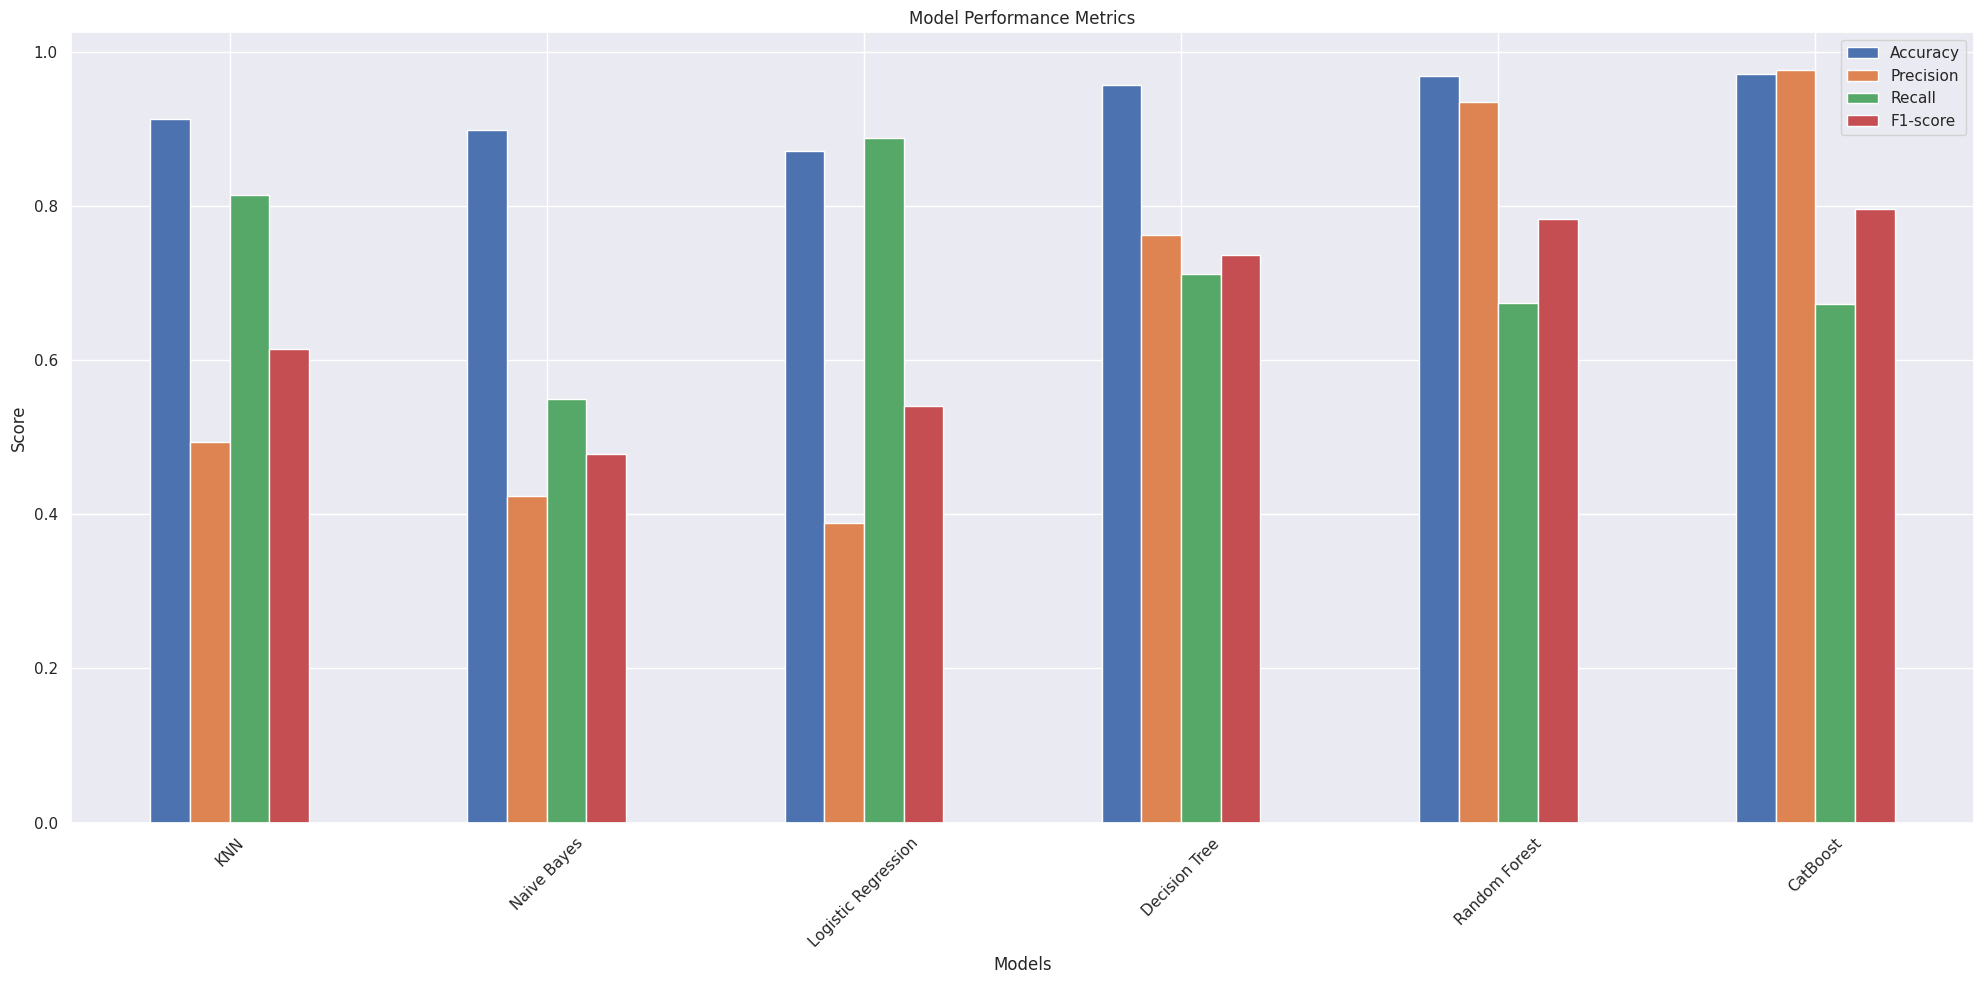

In [71]:
results_df_plot = results_df.set_index("Model")
results_df_plot[['Accuracy', 'Precision', 'Recall', 'F1-score']].plot(kind='bar', figsize=(20,10))
plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Model Performance Metrics')
plt.xticks(rotation=45)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

#8.Performance Comparison (Before vs. After Tuning)

In [98]:
comparison_results = []

models_to_compare = [
    ("Logistic Regression", lr_pipeline, lr_grid.best_estimator_),
    ("KNN", knn_model, knn_grid.best_estimator_),
    ("Naive Bayes", nb_model, nb_grid.best_estimator_),
    ("Decision Tree", dt_default_model, dt_grid.best_estimator_),
    ("Random Forest", rf_default_model, rf_grid.best_estimator_),
    ("CatBoost", cat_pipeline_default, cat_grid.best_estimator_)
]

for name, default_model, tuned_model in models_to_compare:
    default_scores = evaluate_model(default_model, X_test, y_test, name + " (Default)")
    tuned_scores = evaluate_model(tuned_model, X_test, y_test, name + " (Tuned)")

    comparison_results.append({
        "Model": name,
        "Accuracy (Default)": default_scores["Accuracy"],
        "Accuracy (Tuned)": tuned_scores["Accuracy"],
        "Recall (Default)": default_scores["Recall"],
        "Recall (Tuned)": tuned_scores["Recall"],
        "Precision (Default)": default_scores["Precision"],
        "Precision (Tuned)": tuned_scores["Precision"],
        "F1 (Default)": default_scores["F1-score"],
        "F1 (Tuned)": tuned_scores["F1-score"]
    })

comparison_df = pd.DataFrame(comparison_results)
comparison_df

,Model,Accuracy (Default),Accuracy (Tuned),Recall (Default),Recall (Tuned),Precision (Default),Precision (Tuned),F1 (Default),F1 (Tuned)
0,Logistic Regression,0.871200,0.871467,0.887059,0.887843,0.387461,0.388070,0.539342,0.540076
1,KNN,0.900933,0.913067,0.836078,0.813333,0.454972,0.493105,0.589276,0.613973
2,Naive Bayes,0.898000,0.898067,0.549804,0.549804,0.423054,0.423309,0.478172,0.478335
3,Decision Tree,0.971000,0.956533,0.658824,0.711373,1.000000,0.761545,0.794326,0.735604
4,Random Forest,0.971000,0.968267,0.658824,0.673725,1.000000,0.934712,0.794326,0.783045
5,CatBoost,0.970133,0.970733,0.673725,0.672157,0.964085,0.976082,0.793167,0.796098


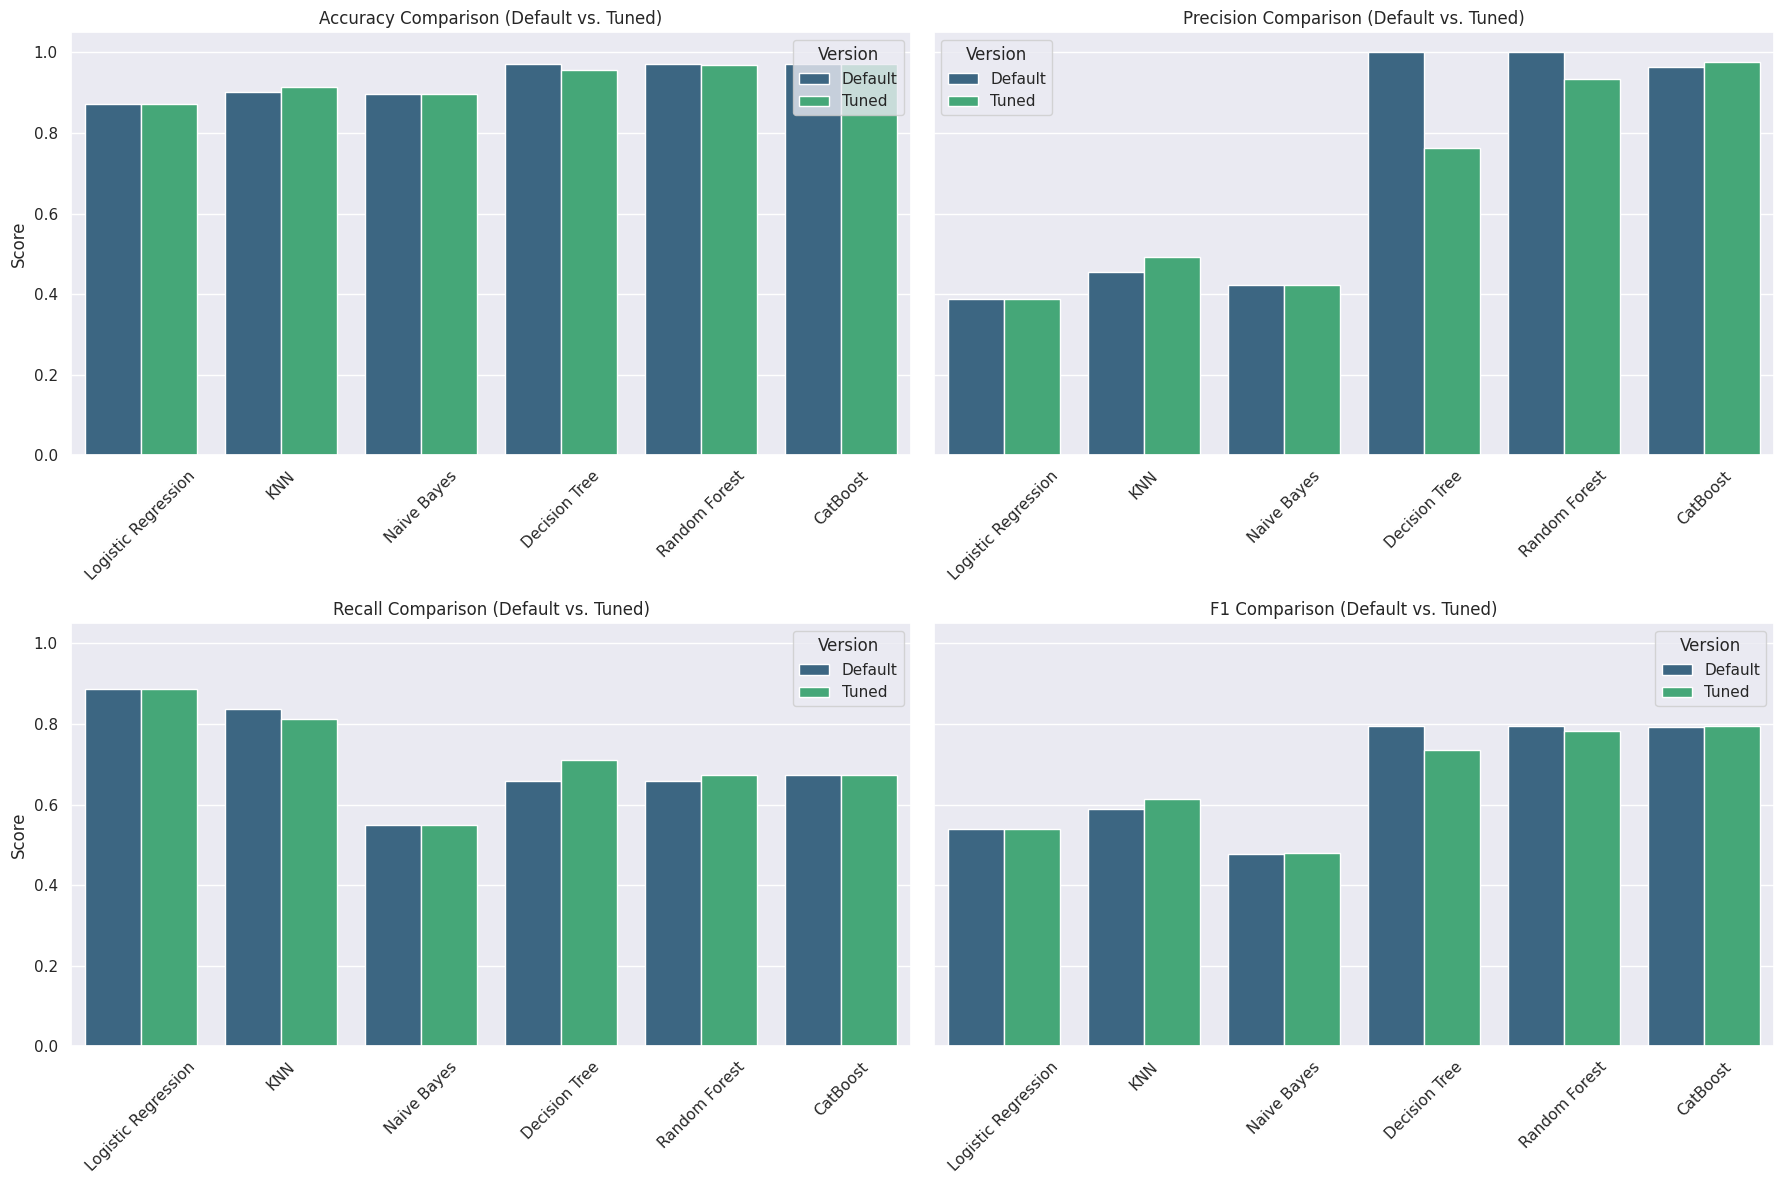

In [101]:
# Prepare data for plotting
comparison_df_melted = comparison_df.melt(id_vars=['Model'], var_name='Metric Type', value_name='Score')

# Separate default and tuned metrics
comparison_df_melted['Metric'] = comparison_df_melted['Metric Type'].apply(lambda x: x.split(' (')[0])
comparison_df_melted['Type'] = comparison_df_melted['Metric Type'].apply(lambda x: x.split(' (')[1].replace(')', ''))

# Create subplots for each metric
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1']
fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharey=True)
axes = axes.flatten()

for i, metric in enumerate(metrics_to_plot):
    subset = comparison_df_melted[comparison_df_melted['Metric'] == metric]
    sns.barplot(x='Model', y='Score', hue='Type', data=subset, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{metric} Comparison (Default vs. Tuned)')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Score')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Version')

plt.tight_layout()
plt.show()

### Final Model Selection

The final model selection was based on the performance of the tuned models, with particular emphasis on achieving a balanced performance across evaluation metrics. Due to the imbalanced nature of the dataset, Accuracy alone was not considered sufficient, and greater importance was placed on F1-score as it reflects a balance between Precision and Recall.

Among all evaluated models, **CatBoost (tuned)** achieved the highest F1-score (0.7961), indicating the best overall balance between correctly identifying diabetic patients and minimizing false positives. Additionally, CatBoost achieved the highest Precision value (0.9761), demonstrating strong confidence in its positive predictions.

Although Logistic Regression achieved a higher Recall, CatBoost was selected as the final model because it provided superior overall performance, stability, and robustness when handling imbalanced data. Furthermore, CatBoost does not require feature scaling and demonstrated consistent performance before and after hyperparameter tuning.

Therefore, CatBoost was chosen as the final model for diabetes classification due to its strong generalization ability and balanced performance across key evaluation metrics.


# 9.Save Model

In [102]:
cat_model = cat_grid.best_estimator_


In [103]:
cat_model.save_model("catboost_model.cbm")


In [104]:
from google.colab import files
files.download("catboost_model.cbm")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

###To reload

In [ ]:
# from catboost import CatBoostClassifier

# loaded_cat = CatBoostClassifier()
# loaded_cat.load_model("catboost_model.cbm")
